Iniciando integración de la ecuación de Liouville-von Neumann...
Integración completada.


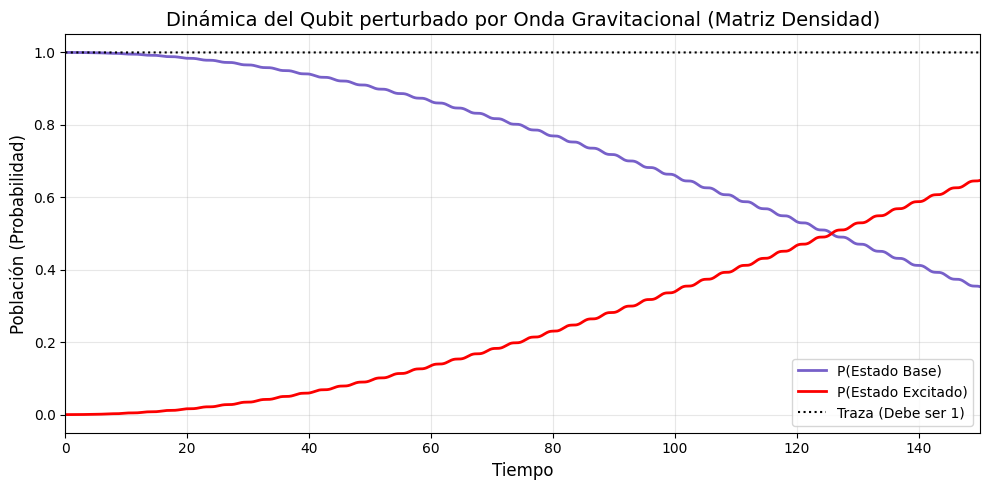

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# =====================================================================
# OBJETIVO 1: Sistema de dos niveles usando Matriz Densidad
# Teoría: Ruggiero (2025) - Analogía Gravitoelectromagnética
# =====================================================================

# 1. Definimos las Matrices de Pauli
sigma_x = np.array([[0, 1], [1, 0]], dtype=complex)
sigma_y = np.array([[0, -1j], [1j, 0]], dtype=complex)
sigma_z = np.array([[1, 0], [0, -1]], dtype=complex)
I = np.eye(2, dtype=complex)

# 2. Parámetros del Sistema (Usamos unidades naturales: hbar = 1, c = 1)

B_0 = 1.0             # Campo magnético constante (para definir la frecuencia natural del sistema)

gamma = 1.0           # Factor de acoplamiento (puede ser ajustado para simular diferentes intensidades de interacción)

omega_0 = gamma * B_0 # Frecuencia natural del sistema (delta de energía)

omega_GW = 1.0        # Frecuencia de la onda gravitacional (Para realizar la simulación en resonancia)

A_cross = 0.05        # Amplitud del strain (h_x)

k_0 = 1.0             # Distancia característica desde el centro del detector

def hamiltoniano_GW(t, omega_gw):
    """
    Construye el Hamiltoniano dependiente del tiempo basado en Ruggiero (2025).
    El Hamiltoniano tiene una parte constante (H0) y una parte oscilatoria (W(t)) que representa la perturbación de la onda gravitacional.
    La perturbación acopla al sistema a través de sigma_x, lo que induce transiciones entre los estados |0> y |1>.
    La fuerza de esta perturbación está determinada por la amplitud del strain y la frecuencia de la onda gravitacional.
    Se asume que el acoplamiento es lineal con el strain, lo cual es una aproximación común en este tipo de sistemas.

    """
    
    # H0: Hamiltoniano no perturbado
    H0 = (omega_0 / 2.0) * sigma_z
    
    # W(t): Perturbación gravito-magnética
    # W_cross define la fuerza de interacción acoplada al strain
    W_cross = (omega_gw**2 / 4.0) * A_cross * k_0
    
    # Perturbación oscilatoria acoplada a sigma_x (para inducir transiciones)
    W_t = W_cross * np.cos(omega_gw * t) * sigma_x
    
    return H0 + W_t

def liouville_von_neumann(t, rho_vec, omega_gw):
    """
    Evalúa la derivada temporal de la matriz densidad.
    solve_ivp requiere vectores 1D, por lo que aplanamos y reconstruimos la matriz.

    """
    # Reconstruir matriz densidad 2x2
    rho = rho_vec.reshape((2, 2))
    H = hamiltoniano_GW(t, omega_gw)
    
    # Conmutador [H, rho]
    conmutador = H @ rho - rho @ H
    drho_dt = -1j * conmutador
    
    # Aplanar a vector 1D para el integrador
    return drho_dt.flatten()

# 3. Condiciones Iniciales
# Iniciaremos en el estado base puro |0> -> rho = |0><0|
rho_0 = np.array([[1, 0], [0, 0]], dtype=complex)
rho_vec_0 = rho_0.flatten()

# 4. Simulación Temporal
tiempos = np.linspace(0, 150, 2000)

print("Iniciando integración de la ecuación de Liouville-von Neumann...")
solucion = solve_ivp(fun=liouville_von_neumann, t_span=(tiempos[0], tiempos[-1]), y0=rho_vec_0, t_eval=tiempos, args=(omega_GW,), rtol=1e-9, atol=1e-9)

# 5. Extracción de Resultados
# Reconstruimos la secuencia de matrices densidad 
rho_t = solucion.y.reshape((2, 2, len(tiempos)))

# La probabilidad de transición al estado excitado |1> es el elemento rho_11
P_excitado = np.real(rho_t[1, 1, :])
P_base = np.real(rho_t[0, 0, :])

print("Integración completada.")

# 6. Gráficamos las probabilidades
plt.figure(figsize=(10, 5))
plt.plot(tiempos, P_base, label='P(Estado Base)', color="#7760c9", linewidth=2)
plt.plot(tiempos, P_excitado, label='P(Estado Excitado)', color="#fc0000", linewidth=2)
plt.plot(tiempos, P_base + P_excitado, 'k:', label='Traza (Debe ser 1)')

plt.title('Dinámica del Qubit perturbado por Onda Gravitacional (Matriz Densidad)', fontsize=14)
plt.xlabel('Tiempo', fontsize=12)
plt.ylabel('Población (Probabilidad)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, 150)
plt.ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()

Extrayendo las componentes del vector de Bloch...
Vectores extraídos. Generando visualización 3D...


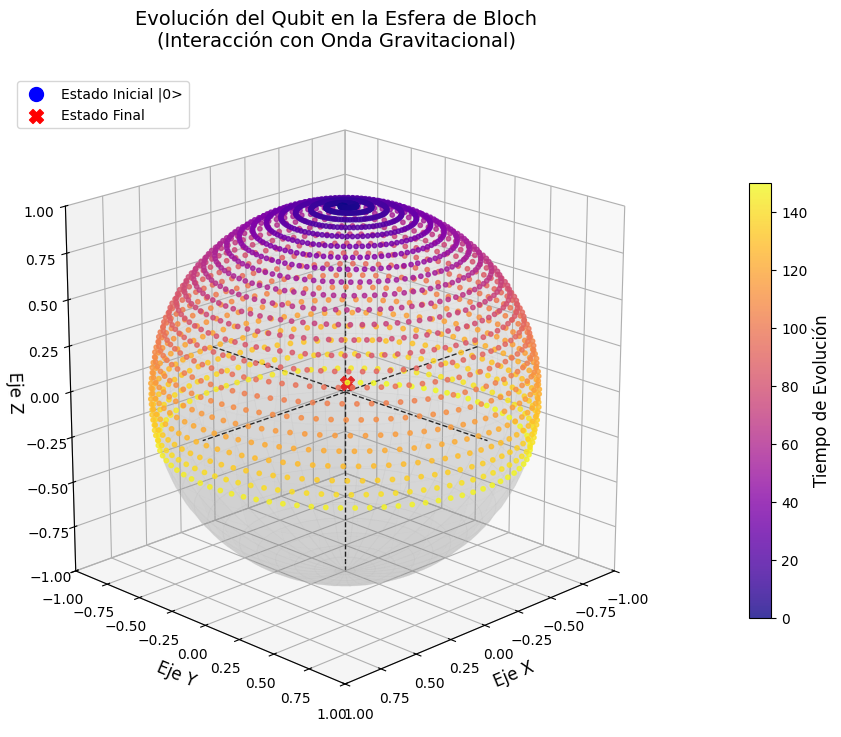

In [6]:
# =====================================================================
# OBJETIVO 2: La Esfera de Bloch 
# =====================================================================
from mpl_toolkits.mplot3d import Axes3D

print("Extrayendo las componentes del vector de Bloch...")

# 1. Inicializamos los arreglos para las componentes r_x, r_y, r_z
r_x = np.zeros(len(tiempos))
r_y = np.zeros(len(tiempos))
r_z = np.zeros(len(tiempos))

# 2. Calculamos r_i = Tr(rho * sigma_i) para cada instante de tiempo

for i in range(len(tiempos)):
    rho_actual = rho_t[:, :, i]

    # np.trace devuelve un complejo, por lo que extraemos la parte real
    r_x[i] = np.real(np.trace(rho_actual @ sigma_x))
    r_y[i] = np.real(np.trace(rho_actual @ sigma_y))
    r_z[i] = np.real(np.trace(rho_actual @ sigma_z))

print("Vectores extraídos. Generando visualización 3D...")

# 3. Configuración de la figura 3D
fig = plt.figure(figsize=(9, 9))
ax = fig.add_subplot(111, projection='3d')

# 4. Dibujamos la esfera de Bloch (como una malla transparente)
u = np.linspace(0, 2 * np.pi, 60)
v = np.linspace(0, np.pi, 60)
x_sphere = np.outer(np.cos(u), np.sin(v))
y_sphere = np.outer(np.sin(u), np.sin(v))
z_sphere = np.outer(np.ones(np.size(u)), np.cos(v))


ax.plot_surface(x_sphere, y_sphere, z_sphere, color='whitesmoke', alpha=0.15, edgecolor='lightgray', lw=0.5) #Agregamos una superficie translúcida

# 5. Dibujamos los ejes cartesianos (X, Y, Z) para referencia
ax.plot([-1, 1], [0, 0], [0, 0], color='black', lw=1, linestyle='--')
ax.plot([0, 0], [-1, 1], [0, 0], color='black', lw=1, linestyle='--')
ax.plot([0, 0], [0, 0], [-1, 1], color='black', lw=1, linestyle='--')

# 6. Graficamos la trayectoria geométrica del estado
# Usamos un mapa de color (colormap) atado al tiempo para ver el sentido de la evolución
scatter = ax.scatter(r_x, r_y, r_z, c=tiempos, cmap='plasma', s=10, alpha=0.8)
cbar = plt.colorbar(scatter, ax=ax, shrink=0.5, pad=0.1)
cbar.set_label('Tiempo de Evolución', fontsize=12)

# resaltamos los puntos inicial y final 
ax.scatter(r_x[0], r_y[0], r_z[0], color='blue', s=100, label='Estado Inicial |0>', zorder=5, marker='o')
ax.scatter(r_x[-1], r_y[-1], r_z[-1], color='red', s=100, label='Estado Final', zorder=5, marker='X')

# 7. etiquetas
ax.set_xlabel('Eje X', fontsize=12)
ax.set_ylabel('Eje Y', fontsize=12)
ax.set_zlabel('Eje Z', fontsize=12)
ax.set_title('Evolución del Qubit en la Esfera de Bloch\n(Interacción con Onda Gravitacional)', fontsize=14, pad=20)
ax.legend(loc='upper left')

# Ajustamos el ángulo inicial para apreciar mejor la precesión
ax.view_init(elev=20, azim=45)

# Forzamos los límites para que la esfera no se deforme
ax.set_xlim([-1, 1])
ax.set_ylim([-1, 1])
ax.set_zlim([-1, 1])
ax.set_box_aspect([1,1,1]) # Proporciones 1:1:1

plt.tight_layout()
plt.show()

In [ ]:
# =====================================================================
# OBJETIVO 2.1: Esfera de Bloch Interactiva con ipywidgets
# Parámetros: Tiempo, Amplitud (Strain) y Frecuencia (Resonancia)
# =====================================================================

import ipywidgets as widgets
from IPython.display import display



# Parámetros fijos
omega_0 = 1.0  # Frecuencia natural del qubit
k_0 = 1.0      # Distancia característica

def graficar_bloch_interactiva(t_max, A_cross, omega_gw):
    """
    Función que recalcula la dinámica y actualiza la esfera de Bloch
    basada en los valores de los sliders.
    """
    # Evitamos t_max = 0 para problemas de integración
    if t_max <= 0.1:
        t_max = 0.1
        
    tiempos = np.linspace(0, t_max, int(t_max * 10)) # Resolución dinámica
    
    # Construcción del Hamiltoniano (Modelo Ruggiero)
    def liouville_von_neumann_int(t, rho_vec):
        H0 = (omega_0 / 2.0) * sigma_z
        W_cross = (omega_gw**2 / 4.0) * A_cross * k_0
        W_t = W_cross * np.cos(omega_gw * t) * sigma_x
        H = H0 + W_t
        
        rho = rho_vec.reshape((2, 2))
        drho_dt = -1j * (H @ rho - rho @ H)
        return drho_dt.flatten()

    # Estado Inicial |0>
    rho_0 = np.array([[1, 0], [0, 0]], dtype=complex)
    
    # Integración rápida
    solucion = solve_ivp(fun=liouville_von_neumann_int, t_span=(0, t_max), y0=rho_0.flatten(), t_eval=tiempos, rtol=1e-6, atol=1e-6) 
    # Se disminuyo la torelancia para una mayor fluidez
    
    rho_t = solucion.y.reshape((2, 2, len(tiempos)))
    
    # Extracción del vector de Bloch
    r_x = np.real(np.trace(rho_t.T @ sigma_x, axis1=1, axis2=2))
    r_y = np.real(np.trace(rho_t.T @ sigma_y, axis1=1, axis2=2))
    r_z = np.real(np.trace(rho_t.T @ sigma_z, axis1=1, axis2=2))
    
    # --- Configuración del Gráfico 3D ---
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # Esfera base
    u = np.linspace(0, 2 * np.pi, 40)
    v = np.linspace(0, np.pi, 40)
    ax.plot_surface(np.outer(np.cos(u), np.sin(v)), 
                    np.outer(np.sin(u), np.sin(v)), 
                    np.outer(np.ones(np.size(u)), np.cos(v)), 
                    color='whitesmoke', alpha=0.1, edgecolor='lightgray', lw=0.3)
    
    # Ejes
    ax.plot([-1, 1], [0, 0], [0, 0], 'k--', lw=0.8)
    ax.plot([0, 0], [-1, 1], [0, 0], 'k--', lw=0.8)
    ax.plot([0, 0], [0, 0], [-1, 1], 'k--', lw=0.8)
    
    # Traza del estado cuántico
    ax.plot(r_x, r_y, r_z, color='teal', lw=2, label='Trayectoria $\\vec{r}(t)$')
    
    # Puntos actual e inicial
    ax.scatter(r_x[0], r_y[0], r_z[0], color='blue', s=60, label='Inicio $|0\\rangle$')
    ax.scatter(r_x[-1], r_y[-1], r_z[-1], color='red', s=80, label=f'Estado a t={t_max:.1f}')
    
    # Estética
    ax.set_xlim([-1, 1])
    ax.set_ylim([-1, 1])
    ax.set_zlim([-1, 1])
    ax.set_box_aspect([1, 1, 1])
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    
    # Título dinámico para mostrar si estamos en resonancia o no
    detuning = np.abs(omega_gw - omega_0)
    if detuning < 0.05:
        estado_res = "¡En Resonancia!"
    else:
        estado_res = f"Fuera de Resonancia ($\\Delta\\omega$ = {detuning:.2f})" 
        
    ax.set_title(f'Dinámica Interactiva del Qubit\n{estado_res}', fontsize=12)
    ax.legend(loc='upper left')
    
    plt.tight_layout()
    plt.show()

# 2. Creación de los Sliders interactivos
interfaz = widgets.interact(
    graficar_bloch_interactiva,
    t_max=widgets.FloatSlider(value=1.0, min=0.1, max=150.0, step=1.0, description='Tiempo t:', layout={'width': '500px'}),
    A_cross=widgets.FloatSlider(value=0.05, min=0.0, max=0.2, step=0.01, description='Strain $A_{\\times}$:', layout={'width': '500px'}),
    omega_gw=widgets.FloatSlider(value=1.0, min=0.5, max=1.5, step=0.05, description='Frecuencia $\\omega_{GW}$:', layout={'width': '500px'})
)

interactive(children=(FloatSlider(value=1.0, description='Tiempo t:', layout=Layout(width='500px'), max=150.0,…

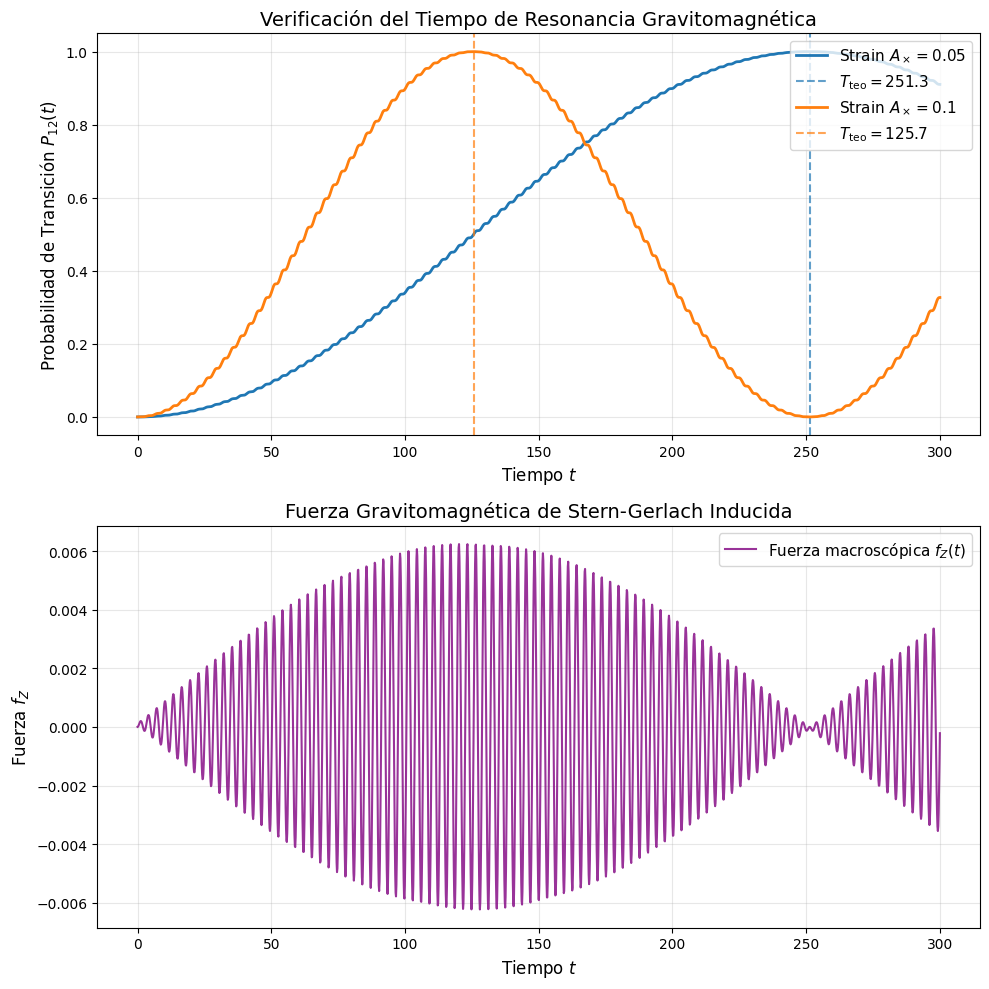

In [8]:
# =====================================================================
# OBJETIVO 3: Verificación Analítica y Fuerza de Stern-Gerlach (Ruggiero 2025)
# =====================================================================


#redefinimos los parámetros para la simulación de Ruggiero 

omega_0 = 1.0   # Frecuencia propia
omega_gw = 1.0  # Nos interesa el caso en resonancia (omega_gw = omega_0)
k_0 = 1.0

# Evaluaremos dos strains distintos para comprobar la Ec. 44 de Ruggiero
A_cross_1 = 0.05
A_cross_2 = 0.10

def simular_ruggiero(A_cross, t_max):
    W_cross = (omega_gw**2 / 4.0) * A_cross * k_0
    
    # Tiempo teórico de Ruggiero (Ec. 44) para alcanzar P=1
    T_teorico = np.pi / W_cross
    
    def liouville(t, rho_vec):
        H0 = (omega_0 / 2.0) * sigma_z
        W_t = W_cross * np.cos(omega_gw * t) * sigma_x
        H = H0 + W_t
        rho = rho_vec.reshape((2, 2))
        return (-1j * (H @ rho - rho @ H)).flatten()

    rho_0 = np.array([[1, 0], [0, 0]], dtype=complex).flatten()
    tiempos = np.linspace(0, t_max, 2000)
    
    sol = solve_ivp(liouville, [0, t_max], rho_0, t_eval=tiempos, rtol=1e-9, atol=1e-9)
    rho_t = sol.y.reshape((2, 2, len(tiempos)))
    

    P_excitado = np.real(rho_t[1, 1, :])
    # Valor esperado <S_y> = (hbar/2) * Tr(rho * sigma_y)
    S_y = 0.5 * np.real(np.trace(rho_t.T @ sigma_y, axis1=1, axis2=2))
    
    return tiempos, P_excitado, S_y, T_teorico


# 2. Corremos la simulación para ambos Strains
t_eval_max = 300
t1, P1, Sy1, T_teo1 = simular_ruggiero(A_cross_1, t_eval_max)
t2, P2, Sy2, T_teo2 = simular_ruggiero(A_cross_2, t_eval_max)

# 3. Cálculo de las Fuerzas de Stern-Gerlach (Ec. de la Sección V de Ruggiero)
# f_Z = (omega^2 / 2c) * <S_Y> * A_cross * sin(omega * T)
F_Z_1 = (omega_gw**2 / 2.0) * Sy1 * A_cross_1 * np.sin(omega_gw * t1)

# 4. Visualización de los Resultados
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))

# --- Gráfico 1: Tiempos de Resonancia ---
ax1.plot(t1, P1, color='#1f77b4', lw=2, label=rf'Strain $A_\times = {A_cross_1}$')
ax1.axvline(T_teo1, color='#1f77b4', linestyle='--', alpha=0.7, label=rf'$T_{{\text{{teo}}}} = {T_teo1:.1f}$')

ax1.plot(t2, P2, color='#ff7f0e', lw=2, label=rf'Strain $A_\times = {A_cross_2}$')
ax1.axvline(T_teo2, color='#ff7f0e', linestyle='--', alpha=0.7, label=rf'$T_{{\text{{teo}}}} = {T_teo2:.1f}$')

ax1.set_title(r'Verificación del Tiempo de Resonancia Gravitomagnética', fontsize=14)
ax1.set_ylabel(r'Probabilidad de Transición $P_{12}(t)$', fontsize=12)
ax1.set_xlabel(r'Tiempo $t$', fontsize=12)
ax1.legend(fontsize=11, loc='upper right')
ax1.grid(True, alpha=0.3)

# --- Gráfico 2: Fuerza de Stern-Gerlach ---
ax2.plot(t1, F_Z_1, color='purple', lw=1.5, alpha=0.8, label=r'Fuerza macroscópica $f_Z(t)$')
ax2.set_title(r'Fuerza Gravitomagnética de Stern-Gerlach Inducida', fontsize=14)
ax2.set_xlabel(r'Tiempo $t$', fontsize=12)
ax2.set_ylabel(r'Fuerza $f_Z$', fontsize=12)
ax2.legend(fontsize=11, loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()